# Average image editor and developer playground

Function to calculate the average of multiple images, outputting it as an average image.

Images should either be in the same template OR aligned to a common image. For now, we will write the function assuming the former. This is so that voxels found in a coordinate are the same voxels across images.

FIX to function: option to align images.

Example usage: average slope image (normalized to MNISymm template) over subjects.

Notebook for developing function and editing it.

## development

In [2]:
# Imports

# model libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image reading libraries
import nibabel as nib
from nilearn import plotting as npl
from nilearn import masking # for masking within-brain voxels

import nitools as nt
import avg_vol as av

from pathlib import Path
import os

In [3]:
# directories
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'
p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')

In [8]:
# loop thorugh all subjs (with function)

# 1. read image

# 2. into world coordinates

# 3. store each array in a list, so we have an array tuple

# 4. average over all arrays

# 5. write back to voxel coordinates

# 6. save image

In [4]:
# test with smaller version of p_df
p_df = p_df.iloc[:8]

NOTE: NEED TO HAVE OPTION TO LOOK FOR FLIPPED FILE IS SUBJ'S LESION IS ON THE OTHER SIDE (WHERE SIDE = RIGHT)

### function input: type (control, patient) for suffix in name of output file
Cut participants df in tutorial (when you call, you can do that, just insert df)

**Inputs**

* suffix for file name, `suffix`

* prefix for file name (e.g. tissue type = wm), `prefix`

* participants dataframe, `p_df`

In [11]:
suffix = 'patients'

This part is just the loop for calling the function

**SUBJECT LOOP FUNCTION - UNIQUE**

Need to make this into its own function with inputs:

* participants dataframe

* file name(s) (str or tuple) - if tuple, check that each file exists

* results_path

* suffix for output file

* function to run

* (optional, default None) output message (str)

In [8]:
p_df

,SN,ID,Centre,Week,week,RefT1,numrun,nslices,Hand,LesionSide,...,surfmvpa,include1,lesiondef,behavior_missing,behavior_blocks,has_mvc,DTImap_missing,CentreNo,machine,subj_id
0,1,2310,CU,W0,0,W0,8,35,b,left,...,1,1,1,0,8,0,0,1,naveed,CU_2310
1,2,2310,CU,W4,4,W0,8,35,b,left,...,1,1,1,0,8,0,0,1,naveed,CU_2310
2,3,2310,CU,W12,12,W0,8,35,b,left,...,1,1,1,0,8,1,0,1,naveed,CU_2310
3,4,2310,CU,W24,24,W0,8,35,b,left,...,1,1,1,0,8,1,0,1,naveed,CU_2310
4,5,2310,CU,W52,52,W0,8,35,b,left,...,1,1,1,3,0,1,0,1,naveed,CU_2310
5,6,2538,CU,W0,0,W0,8,35,b,right,...,1,1,1,0,8,1,0,1,naveed,CU_2538
6,7,2538,CU,W4,4,W0,8,35,b,right,...,1,1,1,0,8,1,0,1,naveed,CU_2538
7,8,2663,CU,W0,0,W0,7,35,b,left,...,1,1,1,0,7,1,0,1,naveed,CU_2663


In [9]:
images_list_str = []

for subj_id in p_df['subj_id'].unique():
    # just need reference week files and file from parent subj directory, so don't need to access all rows.

    # get slope file: flipped file is lesion is on left side

    lesion_side = (p_df.loc[(p_df['subj_id']==subj_id), 'LesionSide'].iloc[0]).strip()

    if lesion_side == 'left':
        indiv_slope_path = f'{anat_dir}/{subj_id}/regression_native/{subj_id}_T1_slope_wm_resliced_flipped.nii.gz'
    else: # this also works on controls
        indiv_slope_path = f'{anat_dir}/{subj_id}/regression_native/{subj_id}_T1_slope_wm_native_resliced.nii.gz'

    
    if not Path(indiv_slope_path).is_file():
        print(f'slope does not exist for {subj_id}')
        continue

    images_list_str.append(indiv_slope_path)
    

    # make a new folder inside subject's week folder for results
    #results_path = Path(base_dir)/'average_slopes_trial/'
    #results_path.mkdir(parents = True)
    #results_path.mkdir(parents=True) # exist_ok = True
    # function goes here____

    # function....
    # output filename: wm_avg_slope_{suffix}.nii.gz

    
    # save image - probably should put this in the function
    

In [16]:
output_img = overall_img(images_list_str)

under construction


In [20]:
indiv_slope_path

'/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/CU_2663/regression_native/CU_2663_T1_slope_wm_resliced_flipped.nii.gz'

In [23]:
temp_affine_slope_img = nib.load(indiv_slope_path)

In [24]:
output_img_nifti = nib.Nifti1Image(output_img, affine = temp_affine_slope_img.affine)
# temporarily using affine from CU_2663 resliced flipped slope's img bc it's already stored in indiv_slope_path, variable in here.
# affine for overall image should be same as template, I think

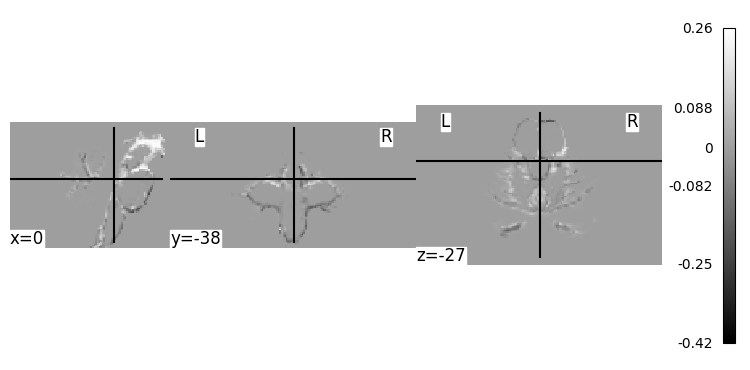

In [25]:
npl.plot_anat(output_img_nifti)

In [26]:
nib.save(output_img_nifti, "sample_img_slope_3subj.nii.gz")

In [ ]:
# I think call above loop inside function? Or do this 

In [ ]:
# loop thorugh all subjs (with function)

# 1. read image

# 2. into world coordinates

# 3. store each array in a list, so we have an array tuple

# 4. average over all arrays

# 5. write back to voxel coordinates

# 6. save image

In [ ]:
def overall_img( # fix: fcn name
        images, # str tuple
        stat = 'sum' # default: sum - fix: option for different stats, e.g. make dictionary for stat input and numpy stat (e.g. np.sum for arrays)
):
    print("under construction")

    # list to store image arrays
    img_arr = []

    # get voxel data for all imgs
    for img in images:
        nifti_img = nib.load(img)
        img_arr.append(nifti_img.get_fdata())
    
    # question: should we get this in world coordinates? Does it matter since they're all deformed to thes ame tempalte (changing underlyign voxel data)?
    # should read suit.reslice code and figure this out

    # check: how should we compute this - voxel-wise addition (or stat)? I think it should be a voxel-wise operation.
    # So should check that our operation is doing this correclty.

    output_img = np.sum(img_arr, axis = 0) # trying np.sum addition along a given axis. Just as a placeholder for now I guess.

    return output_img # array rn

Not sure about this function...the architecture of it probably works, but check how we calculate the overall image (array).

Probably should extract each of i, j, k axes, calculate the statistic over that, and then put back into an array.

So `np.sum`, `np.mean` take the (sum, mean) along either the flattened array (default) or a specified axis (or multiple, if supplied).

So perhaps we can put (as `axis`) the i, j, k indices